# Детектор несогласованности «текст ↔ оценка» (TextCNN + звезда)
### Групповой проект №5 · Deep Learning · НИУ ВШЭ БИ

**Бизнес-задача.** Ловить отзывы, где **текст не соответствует выставленной звезде**. Применение:
1. **чистка данных / достоверность рейтинга** — рассогласованные оценки понижаем в весе при расчёте
   среднего и как «шумные метки» для рекомендателя (Задача 1);
2. **UX-подсказка автору при публикации** — «вы написали скорее негативно, но поставили 5★. Всё верно?».

**Как получили метки.** Реальных меток «фейк/ошибка» нет. Поэтому в `scripts/build_mismatch_dataset.py`
половину отзывов оставили как есть (`label=0`, согласовано), а второй половине **испортили оценку**
(новый `stars` с `|new−orig|>1`, `label=1`). Распределение `stars` сделано **одинаковым** в обоих
классах (режим `balanced`), поэтому по одной только оценке угадать метку нельзя.

**Что обучаем (3 модели — для честной проверки):**

| Модель | Вход | Ожидание |
|---|---|---|
| **stars-only** | только звезда | ~0.5 ROC-AUC → подтверждает, что shortcut по звезде убран |
| **text-only** | только текст | ~0.5 → текст в обоих классах одинаковый, сам по себе метку не несёт |
| **text + stars** | текст и звезда | должна бить оба — значит выучила именно **согласованность** текста и оценки |

> Признаки — только `text` и `stars`; `orig_stars`/id **не используем** (это утечка). Метрика —
> ROC-AUC (есть синтетические метки, поэтому измеримо честно).

In [1]:
import os
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import sys, json, time, re, random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, confusion_matrix, roc_curve, precision_recall_fscore_support

_PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(_PROJECT))
from _constants import MISMATCH_PARQUET, ARTIFACTS, REPORTS, ENABLE_ARTIFACTS, ENABLE_LOGGING

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available() else "cpu")

SMOKE = os.environ.get("YELP_SMOKE") == "1"
SAMPLE_TOTAL = 3000 if SMOKE else 200_000
MAXLEN       = 64 if SMOKE else 200
EPOCHS       = 1 if SMOKE else 5
BS           = 128

NB = "Task2_mismatch"
def savefig(name):
    if not ENABLE_ARTIFACTS:
        return
    ARTIFACTS.mkdir(parents=True, exist_ok=True)
    plt.tight_layout(); plt.savefig(ARTIFACTS / f"{NB}_{name}.png", bbox_inches="tight", dpi=140)

print("device:", device, "| SMOKE:", SMOKE)

device: mps | SMOKE: False


## 1. Данные

Грузим синтетический датасет. Признаки — `text` и `stars`, таргет — `label`. Проверяем, что
распределение `stars` действительно одинаковое в обоих классах (иначе была бы лазейка).

In [2]:
df = pd.read_parquet(MISMATCH_PARQUET, columns=["text", "stars", "label"]).dropna(subset=["text"])
df = df[df["text"].str.len() > 0].copy()
df["stars"] = df["stars"].astype(int)

if SAMPLE_TOTAL and len(df) > SAMPLE_TOTAL:
    df = df.sample(SAMPLE_TOTAL, random_state=SEED).reset_index(drop=True)

print(f"строк: {len(df):,} | label=0: {(df['label']==0).sum():,} | label=1: {(df['label']==1).sum():,}")
chk = df.groupby("label")["stars"].value_counts(normalize=True).unstack().round(3)
print("распределение stars по классам (должно совпадать):")
print(chk.to_string())

train_df, tmp = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(tmp, test_size=0.5, stratify=tmp["label"], random_state=SEED)
print(f"\ntrain={len(train_df):,} val={len(val_df):,} test={len(test_df):,}")

строк: 200,000 | label=0: 100,283 | label=1: 99,717
распределение stars по классам (должно совпадать):
stars      1      2      3      4      5
label                                   
0      0.161  0.078  0.097  0.205  0.458
1      0.161  0.079  0.097  0.206  0.457

train=160,000 val=20,000 test=20,000


## 2. Токенизация (словарь по train)

In [3]:
TOKEN_RE = re.compile(r"[a-z]+")
def tokenize(t): return TOKEN_RE.findall(str(t).lower())

MIN_FREQ = 2
cnt = Counter()
for t in train_df["text"]:
    cnt.update(tokenize(t))
itos = ["<pad>", "<unk>"] + [w for w, c in cnt.items() if c >= MIN_FREQ]
stoi = {w: i for i, w in enumerate(itos)}
VOCAB = len(itos); PAD_IDX = 0; MIN_LEN = 5

def encode(t): return [stoi.get(w, 1) for w in tokenize(t)][:MAXLEN]

class MismatchDS(Dataset):
    def __init__(self, d):
        self.x = [encode(t) for t in d["text"]]
        self.s = (d["stars"].to_numpy() - 1).astype(int)   # звезда 1..5 -> индекс 0..4
        self.y = d["label"].to_numpy().astype(int)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.x[i], self.s[i], self.y[i]

def collate(batch):
    xs, ss, ys = zip(*batch)
    maxlen = max(MIN_LEN, max(len(x) for x in xs))
    ids = torch.zeros(len(xs), maxlen, dtype=torch.long)
    for i, x in enumerate(xs):
        if x: ids[i, :len(x)] = torch.tensor(x, dtype=torch.long)
    return ids, torch.tensor(ss, dtype=torch.long), torch.tensor(ys, dtype=torch.long)

def make_loader(d, shuffle):
    return DataLoader(MismatchDS(d), batch_size=BS, shuffle=shuffle, collate_fn=collate)

tr_loader = make_loader(train_df, True)
va_loader = make_loader(val_df, False)
te_loader = make_loader(test_df, False)
print("словарь:", f"{VOCAB:,}")

словарь: 48,368


## 3. Модель

Единая сеть с переключателями `use_text` / `use_stars` — так stars-only, text-only и text+stars
отличаются только входами, а архитектура головы одна (честное сравнение):
- текст → TextCNN (свёртки 3/4/5 → max-pool);
- звезда → обучаемый эмбеддинг (5 значений);
- признаки конкатенируются → dropout → линейный слой на 2 класса.

In [4]:
class MismatchNet(nn.Module):
    def __init__(self, vocab, use_text=True, use_stars=True,
                 emb=128, n_filters=100, ks=(3, 4, 5), star_dim=16, drop=0.5):
        super().__init__()
        self.use_text, self.use_stars = use_text, use_stars
        feat = 0
        if use_text:
            self.emb = nn.Embedding(vocab, emb, padding_idx=PAD_IDX)
            self.convs = nn.ModuleList([nn.Conv1d(emb, n_filters, k) for k in ks])
            feat += n_filters * len(ks)
        if use_stars:
            self.star_emb = nn.Embedding(5, star_dim)
            feat += star_dim
        self.drop = nn.Dropout(drop)
        self.fc = nn.Linear(feat, 2)
    def forward(self, ids, star):
        parts = []
        if self.use_text:
            e = self.emb(ids).transpose(1, 2)
            parts.append(torch.cat([torch.relu(c(e)).max(dim=2).values for c in self.convs], dim=1))
        if self.use_stars:
            parts.append(self.star_emb(star))
        return self.fc(self.drop(torch.cat(parts, dim=1)))

def n_params(m): return sum(p.numel() for p in m.parameters())

## 4. Цикл обучения (бинарная классификация, метрика — ROC-AUC)

In [5]:
loss_fn = nn.CrossEntropyLoss()

def run_epoch(model, loader, train, opt):
    model.train() if train else model.eval()
    tot = loss_sum = 0.0; probs = []; gts = []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for ids, star, y in loader:
            ids, star, y = ids.to(device), star.to(device), y.to(device)
            logits = model(ids, star)
            loss = loss_fn(logits, y)
            if train:
                opt.zero_grad(); loss.backward(); opt.step()
            loss_sum += loss.item() * len(y); tot += len(y)
            probs += torch.softmax(logits, 1)[:, 1].detach().cpu().tolist()
            gts += y.cpu().tolist()
    preds = [p > 0.5 for p in probs]
    return (loss_sum / tot, accuracy_score(gts, preds), f1_score(gts, preds),
            roc_auc_score(gts, probs), np.array(probs), np.array(gts))

def train_model(name, model, epochs=EPOCHS, lr=1e-3):
    model.to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    hist, best_auc, best_state = [], -1.0, None
    for ep in range(1, epochs + 1):
        t0 = time.time()
        trl, tra, trf, tau, *_ = run_epoch(model, tr_loader, True, opt)
        vll, vaa, vaf, vau, *_ = run_epoch(model, va_loader, False, opt)
        hist.append({"epoch": ep, "train_loss": trl, "val_loss": vll,
                     "val_acc": vaa, "val_f1": vaf, "val_auc": vau})
        if vau > best_auc:
            best_auc = vau
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f"  [{name}] ep{ep}/{epochs} loss={trl:.3f} val_auc={vau:.3f} "
              f"val_f1={vaf:.3f} val_acc={vaa:.3f} ({time.time()-t0:.0f}s)")
    if best_state: model.load_state_dict(best_state)
    return hist

@torch.no_grad()
def evaluate(model, loader):
    model.eval(); probs = []; gts = []
    for ids, star, y in loader:
        ids, star = ids.to(device), star.to(device)
        probs += torch.softmax(model(ids, star), 1)[:, 1].cpu().tolist()
        gts += y.tolist()
    return np.array(gts), np.array(probs)

def log_run(name, model, hist, gts, probs):
    if not ENABLE_LOGGING:
        return
    (REPORTS / "runs").mkdir(parents=True, exist_ok=True)
    json.dump({"model": name, "params": n_params(model), "history": hist,
               "test_auc": float(roc_auc_score(gts, probs)),
               "test_f1": float(f1_score(gts, probs > 0.5))},
              open(REPORTS / "runs" / f"mismatch_{name}.json", "w"), indent=2)
    if ENABLE_ARTIFACTS:
        (ARTIFACTS / "models").mkdir(parents=True, exist_ok=True)
        torch.save(model.state_dict(), ARTIFACTS / "models" / f"mismatch_{name}.pt")

## Логирование экспериментов (MLflow)

In [ ]:
import mlflow

mlflow.set_tracking_uri(f"sqlite:///{_PROJECT}/mlflow.db")
EXPERIMENT = "task2_mismatch"
mlflow.set_experiment(EXPERIMENT)

LOGS = _PROJECT / "logs" / EXPERIMENT


def log_dir(name):
    safe = re.sub(r"[^\w.-]+", "_", name).strip("_.") or "run"
    d = LOGS / safe
    d.mkdir(parents=True, exist_ok=True)
    return d


def log_run(name, model, hist, gts, probs):
    with mlflow.start_run(run_name=name):
        mlflow.log_param("params", n_params(model))
        for h in hist:
            mlflow.log_metric("val_auc", h["val_auc"], step=h["epoch"])
        mlflow.log_metric("test_auc", roc_auc_score(gts, probs))
        mlflow.log_metric("test_f1", f1_score(gts, probs > 0.5))
        torch.save(model.state_dict(), log_dir(name) / "model.pt")

## 5. Обучаем три модели

In [6]:
configs = [
    ("stars-only", dict(use_text=False, use_stars=True)),
    ("text-only",  dict(use_text=True,  use_stars=False)),
    ("text+stars", dict(use_text=True,  use_stars=True)),
]
results = {}
for name, kw in configs:
    print(f"=== {name} ===")
    torch.manual_seed(SEED)
    model = MismatchNet(VOCAB, **kw)
    hist = train_model(name, model)
    gts, probs = evaluate(model, te_loader)
    results[name] = {"hist": hist, "gts": gts, "probs": probs, "params": n_params(model)}
    log_run(name, model, hist, gts, probs)
    print(f"  -> test ROC-AUC={roc_auc_score(gts, probs):.3f}")
    if name == "text+stars":
        best_model = model

=== stars-only ===


  [stars-only] ep1/5 loss=0.712 val_auc=0.494 val_f1=0.578 val_acc=0.496 (5s)


  [stars-only] ep2/5 loss=0.694 val_auc=0.504 val_f1=0.592 val_acc=0.505 (5s)


  [stars-only] ep3/5 loss=0.694 val_auc=0.499 val_f1=0.578 val_acc=0.496 (5s)


  [stars-only] ep4/5 loss=0.694 val_auc=0.500 val_f1=0.239 val_acc=0.499 (5s)


...

  [text+stars] ep2/5 loss=0.683 val_auc=0.627 val_f1=0.647 val_acc=0.590 (44s)


  [text+stars] ep3/5 loss=0.673 val_auc=0.628 val_f1=0.554 val_acc=0.601 (45s)


  [text+stars] ep4/5 loss=0.660 val_auc=0.622 val_f1=0.591 val_acc=0.597 (44s)


  [text+stars] ep5/5 loss=0.642 val_auc=0.613 val_f1=0.595 val_acc=0.590 (44s)


  -> test ROC-AUC=0.631


## 6. Сравнение

,параметры,test ROC-AUC,test F1,test accuracy
модель,,,,
stars-only,114,0.502,0.590,0.502
text-only,"6,345,606",0.629,0.626,0.598
text+stars,"6,345,718",0.631,0.554,0.602


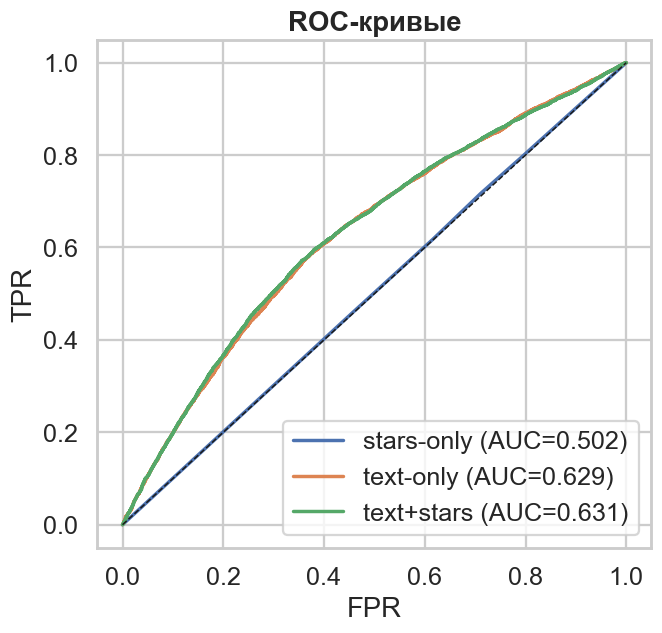

In [7]:
rows = []
for name, r in results.items():
    pred = r["probs"] > 0.5
    rows.append({"модель": name, "параметры": r["params"],
                 "test ROC-AUC": roc_auc_score(r["gts"], r["probs"]),
                 "test F1": f1_score(r["gts"], pred),
                 "test accuracy": accuracy_score(r["gts"], pred)})
comp = pd.DataFrame(rows).set_index("модель")
display(comp.style.format({"параметры": "{:,.0f}", "test ROC-AUC": "{:.3f}",
                           "test F1": "{:.3f}", "test accuracy": "{:.3f}"}))

fig, ax = plt.subplots(figsize=(6.5, 6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(r["gts"], r["probs"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(r['gts'], r['probs']):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("ROC-кривые"); ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.legend()
savefig("roc_curves"); plt.show()

## 7. Бизнес-применение: порог и подсказка автору

У нас есть синтетические метки, поэтому операционную точку можно выбрать честно. Смотрим
распределение `P(mismatch)` основной модели и подбираем порог под сценарий «переспросить автора»:
высокий `P(mismatch)` → показываем подсказку «вы написали иначе, чем оценили — всё верно?».

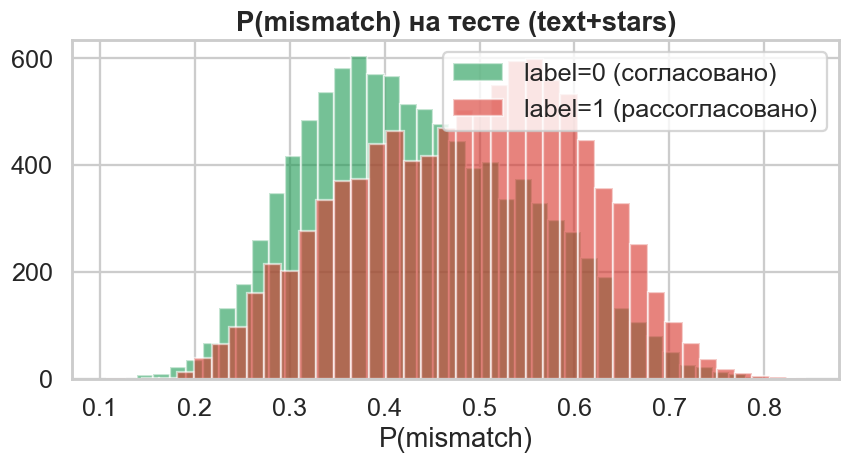

 порог  precision   recall  flagged %
  0.50      0.627    0.497      39.5%
  0.70      0.676    0.021       1.6%
  0.80      0.714    0.001       0.0%
  0.90      0.000    0.000       0.0%


In [8]:
gts, probs = results["text+stars"]["gts"], results["text+stars"]["probs"]
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(probs[gts == 0], bins=40, alpha=.6, label="label=0 (согласовано)", color="#1a9850")
ax.hist(probs[gts == 1], bins=40, alpha=.6, label="label=1 (рассогласовано)", color="#d73027")
ax.set_title("P(mismatch) на тесте (text+stars)"); ax.set_xlabel("P(mismatch)"); ax.legend()
savefig("prob_hist"); plt.show()

print(f"{'порог':>6} {'precision':>10} {'recall':>8} {'flagged %':>10}")
for thr in [0.5, 0.7, 0.8, 0.9]:
    pred = probs > thr
    p, r, _, _ = precision_recall_fscore_support(gts, pred, average="binary", zero_division=0)
    print(f"{thr:>6.2f} {p:>10.3f} {r:>8.3f} {pred.mean()*100:>9.1f}%")

In [9]:
# Примеры, которые модель уверенно пометила как рассогласованные (для UX-подсказки)
test_view = test_df.reset_index(drop=True).copy()
test_view["p_mismatch"] = probs
flagged = test_view[(test_view["p_mismatch"] > 0.9)].sort_values("p_mismatch", ascending=False)
print(f"Помечено как mismatch (P>0.9): {len(flagged):,} из {len(test_view):,}")
for _, r in flagged.head(4).iterrows():
    print(f"\n  ★{r['stars']} | P(mismatch)={r['p_mismatch']:.2f} | label={r['label']}")
    print(f"    {str(r['text'])[:160]}...")

Помечено как mismatch (P>0.9): 0 из 20,000


**!!!!!!!! ДИСБАЛАНС: классы выровнены 50/50 !!!!!!!!**

## 8. Выводы

- **stars-only** даёт ~0.5 AUC — подтверждает, что в данных нет лазейки по одной звезде
  (распределение оценок специально выровнено между классами).
- **text-only** тоже ~0.5 — логично: текст в обоих классах одинаковый, без оценки рассогласование
  не определить.
- **text + stars** заметно выше обоих — значит модель выучила именно **согласованность текста и
  выставленной оценки**, а не угадывает по отдельному признаку. Это и есть рабочий сигнал.

**Куда идёт в продукт.** На публикации отзыва считаем `P(mismatch)`; при высоком значении —
ненавязчивая подсказка «вы написали иначе, чем оценили — всё верно?». Оффлайн — те же оценки с
высоким `P(mismatch)` понижаем в весе при расчёте рейтинга и как шумные метки для рекомендателя.

**Честные оговорки.** Метки синтетические (порча оценки), поэтому это детектор *рассогласования*,
а не «фейка»: реальные накрутки/сарказм/смешанные отзывы он поймает лишь частично, и порог выбран
на синтетике. Для продакшна нужна валидация на размеченной вручную выборке.